# Inteligência Artificial Generativa na Medicina Diagnóstica para Identificação de Subfenótipos de Sepse

**TCC – MBA Data Science e Analytics | USP/ESALQ**  
**Aluno:** João Gabriel Pereira Ferreira  
**Orientador:** Prof. Dr. Renato Máximo Sátiro

---

## Estrutura do Notebook

| Etapa | Descrição | Bibliotecas |
|-------|-----------|-------------|
| 0 | Configuração e imports | pandas, numpy, sklearn, sdv, sdmetrics, matplotlib, seaborn |
| 1 | Extração e estruturação dos dados MIMIC-III Demo | pandas |
| 2 | Pré-processamento | scikit-learn |
| 3 | Expansão sintética com CTGAN | SDV |
| 4 | Avaliação da qualidade sintética | SDMetrics |
| 5 | Clustering com GMM + Silhouette + PCA | scikit-learn |
| 6 | Análise clínica dos agrupamentos | pandas |

> **Nota:** O MIMIC-III Clinical Database Demo é de acesso aberto via PhysioNet (https://physionet.org/content/mimiciii-demo/1.4/).  
> Caso os arquivos CSV não estejam disponíveis localmente, a **Seção 1.2** gera dados clínicos simulados  
> com distribuições compatíveis com a literatura (Seymour et al., 2019), permitindo execução completa do pipeline.


## Seção 0 — Configuração e Importações


In [1]:
# ─── Bibliotecas padrão e de ciência de dados ───────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd

# ─── Visualização ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Pré-processamento e aprendizado de máquina (scikit-learn) ───────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold

# ─── Geração sintética (SDV / CTGAN) ─────────────────────────────────────────
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ─── Avaliação de dados sintéticos (SDMetrics) ───────────────────────────────
from sdmetrics.reports.single_table import QualityReport

# ─── Configurações gerais ─────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

MIMIC_DIR = '.'  # ajuste para o caminho local dos CSVs
print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


## Seção 1 — Extração e Estruturação dos Dados

### 1.1 Leitura dos arquivos MIMIC-III Demo (quando disponíveis)

As tabelas utilizadas são: `PATIENTS`, `ADMISSIONS`, `ICUSTAYS`, `CHARTEVENTS`,  
`LABEVENTS`, `DIAGNOSES_ICD` e `PRESCRIPTIONS`.


In [2]:
def load_mimic(mimic_dir: str) -> dict[str, pd.DataFrame]:
    """Carrega as tabelas do MIMIC-III Demo a partir de um diretório local."""
    tables = {
        'patients'     : 'PATIENTS.csv',
        'admissions'   : 'ADMISSIONS.csv',
        'icustays'     : 'ICUSTAYS.csv',
        'chartevents'  : 'CHARTEVENTS.csv',
        'labevents'    : 'LABEVENTS.csv',
        'diagnoses_icd': 'DIAGNOSES_ICD.csv',
        'prescriptions': 'PRESCRIPTIONS.csv',
    }
    data = {}
    for key, fname in tables.items():
        fpath = os.path.join(mimic_dir, fname)
        if os.path.exists(fpath):
            data[key] = pd.read_csv(fpath, low_memory=False)
            print(f'  {fname:30s}: {data[key].shape[0]:>6} linhas, {data[key].shape[1]:>3} colunas')
        else:
            print(f'  {fname:30s}: NÃO ENCONTRADO')
    return data


mimic_available = os.path.exists(os.path.join(MIMIC_DIR, 'PATIENTS.csv'))

if mimic_available:
    print('MIMIC-III Demo detectado. Carregando tabelas...')
    raw = load_mimic(MIMIC_DIR)
else:
    print('MIMIC-III Demo NÃO encontrado localmente.')
    print('A Seção 1.2 gerará dados clínicos simulados compatíveis com a literatura.')


MIMIC-III Demo detectado. Carregando tabelas...
  PATIENTS.csv                  :    100 linhas,   8 colunas
  ADMISSIONS.csv                :    129 linhas,  19 colunas
  ICUSTAYS.csv                  :    136 linhas,  12 colunas


  CHARTEVENTS.csv               : 758355 linhas,  15 colunas
  LABEVENTS.csv                 :  76074 linhas,   9 colunas
  DIAGNOSES_ICD.csv             :   1761 linhas,   5 colunas
  PRESCRIPTIONS.csv             :  10398 linhas,  19 colunas


### 1.2 Geração de dados clínicos simulados (fallback)

Quando o MIMIC-III Demo não está disponível, utilizamos distribuições clínicas  
baseadas em Seymour et al. (2019) para gerar uma base de trabalho com **100 pacientes**  
e perfis fenotípicos latentes compatíveis com os subgrupos de sepse descritos na literatura.

Os quatro perfis simulados (Alfa, Beta, Gama, Delta) reproduzem aproximadamente  
as características dos fenótipos α, β, γ e δ do estudo de Seymour et al. (2019).


In [3]:
def gerar_dados_simulados(n: int = 100, seed: int = 42) -> pd.DataFrame:
    """
    Gera base clínica simulada com perfis fenotípicos de sepse
    baseados nas distribuições de Seymour et al. (2019).

    Fenótipos:
      Alfa  – disfunção moderada, melhor prognóstico
      Beta  – hiperinflamatório, maior mortalidade
      Gama  – disfunção renal predominante
      Delta – disfunção hepática/choque, pior prognóstico
    """
    rng = np.random.default_rng(seed)
    n4 = n // 4
    rem = n - 3 * n4

    # ── Fenótipo Alfa (n4 pacientes) ──────────────────────────────────────────
    alfa = pd.DataFrame({
        'age'              : rng.normal(62, 12, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(88, 15, n4).clip(40, 180),
        'resp_rate'        : rng.normal(18, 4, n4).clip(8, 40),
        'spo2'             : rng.normal(96, 2, n4).clip(70, 100),
        'temp_c'           : rng.normal(37.6, 0.8, n4).clip(35, 41),
        'sbp'              : rng.normal(112, 18, n4).clip(60, 200),
        'lactate'          : rng.normal(1.8, 0.7, n4).clip(0.5, 10),
        'creatinine'       : rng.normal(1.1, 0.4, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(0.9, 0.5, n4).clip(0.1, 20),
        'wbc'              : rng.normal(11, 4, n4).clip(1, 40),
        'platelet'         : rng.normal(210, 60, n4).clip(10, 600),
        'sodium'           : rng.normal(138, 4, n4).clip(120, 160),
        'potassium'        : rng.normal(4.0, 0.5, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.85, 0.15]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.80, 0.20]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.95, 0.05]),
        'fenotype'         : 'Alfa',
    })

    # ── Fenótipo Beta (hiperinflamatório) ─────────────────────────────────────
    beta = pd.DataFrame({
        'age'              : rng.normal(54, 14, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(108, 20, n4).clip(40, 180),
        'resp_rate'        : rng.normal(24, 6, n4).clip(8, 40),
        'spo2'             : rng.normal(93, 4, n4).clip(70, 100),
        'temp_c'           : rng.normal(38.9, 1.0, n4).clip(35, 41),
        'sbp'              : rng.normal(98, 22, n4).clip(60, 200),
        'lactate'          : rng.normal(3.5, 1.2, n4).clip(0.5, 12),
        'creatinine'       : rng.normal(1.6, 0.8, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(1.5, 1.0, n4).clip(0.1, 20),
        'wbc'              : rng.normal(18, 7, n4).clip(1, 40),
        'platelet'         : rng.normal(160, 80, n4).clip(10, 600),
        'sodium'           : rng.normal(136, 5, n4).clip(120, 160),
        'potassium'        : rng.normal(4.3, 0.7, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.55, 0.45]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.45, 0.55]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.68, 0.32]),
        'fenotype'         : 'Beta',
    })

    # ── Fenótipo Gama (disfunção renal) ───────────────────────────────────────
    gama = pd.DataFrame({
        'age'              : rng.normal(70, 10, n4).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], n4),
        'heart_rate'       : rng.normal(82, 14, n4).clip(40, 180),
        'resp_rate'        : rng.normal(20, 5, n4).clip(8, 40),
        'spo2'             : rng.normal(94, 3, n4).clip(70, 100),
        'temp_c'           : rng.normal(37.2, 0.7, n4).clip(35, 41),
        'sbp'              : rng.normal(105, 16, n4).clip(60, 200),
        'lactate'          : rng.normal(2.2, 0.9, n4).clip(0.5, 10),
        'creatinine'       : rng.normal(3.8, 1.5, n4).clip(0.3, 15),
        'bilirubin'        : rng.normal(0.8, 0.4, n4).clip(0.1, 20),
        'wbc'              : rng.normal(10, 4, n4).clip(1, 40),
        'platelet'         : rng.normal(190, 70, n4).clip(10, 600),
        'sodium'           : rng.normal(139, 5, n4).clip(120, 160),
        'potassium'        : rng.normal(5.0, 0.8, n4).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], n4, p=[0.70, 0.30]),
        'mechanical_vent'  : rng.choice([0, 1], n4, p=[0.65, 0.35]),
        'hospital_mortality': rng.choice([0, 1], n4, p=[0.78, 0.22]),
        'fenotype'         : 'Gama',
    })

    # ── Fenótipo Delta (choque / hepático) ────────────────────────────────────
    delta = pd.DataFrame({
        'age'              : rng.normal(66, 11, rem).clip(18, 90),
        'gender'           : rng.choice(['M', 'F'], rem),
        'heart_rate'       : rng.normal(115, 22, rem).clip(40, 180),
        'resp_rate'        : rng.normal(26, 7, rem).clip(8, 40),
        'spo2'             : rng.normal(91, 5, rem).clip(70, 100),
        'temp_c'           : rng.normal(38.5, 1.1, rem).clip(35, 41),
        'sbp'              : rng.normal(88, 20, rem).clip(60, 200),
        'lactate'          : rng.normal(5.2, 2.0, rem).clip(0.5, 15),
        'creatinine'       : rng.normal(2.4, 1.2, rem).clip(0.3, 15),
        'bilirubin'        : rng.normal(5.8, 3.0, rem).clip(0.1, 30),
        'wbc'              : rng.normal(14, 6, rem).clip(1, 40),
        'platelet'         : rng.normal(100, 60, rem).clip(10, 600),
        'sodium'           : rng.normal(135, 6, rem).clip(120, 160),
        'potassium'        : rng.normal(4.8, 0.9, rem).clip(2.5, 7),
        'vasopressor'      : rng.choice([0, 1], rem, p=[0.30, 0.70]),
        'mechanical_vent'  : rng.choice([0, 1], rem, p=[0.25, 0.75]),
        'hospital_mortality': rng.choice([0, 1], rem, p=[0.45, 0.55]),
        'fenotype'         : 'Delta',
    })

    df = pd.concat([alfa, beta, gama, delta], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    df['subject_id'] = range(1, len(df) + 1)
    return df


if not mimic_available:
    df_original = gerar_dados_simulados(n=100)
    print(f'Base simulada gerada: {df_original.shape[0]} pacientes, {df_original.shape[1]} variáveis')
    print('\nDistribuição de fenótipos:')
    print(df_original['fenotype'].value_counts())


### 1.3 Estruturação da base MIMIC-III Demo (quando disponível)

Quando o MIMIC-III Demo está disponível, esta seção extrai e combina as variáveis  
relevantes para caracterização fenotípica da sepse a partir das tabelas brutas.


In [4]:
def estruturar_mimic(raw: dict) -> pd.DataFrame:
    """
    Extrai e combina variáveis clínicas a partir das tabelas MIMIC-III Demo.
    Retorna um DataFrame no mesmo formato da base simulada.
    """
    # ── Dados demográficos ────────────────────────────────────────────────────
    pts = raw['patients'][['subject_id', 'gender', 'dob']].copy()
    adm = raw['admissions'][['subject_id', 'hadm_id', 'admittime',
                              'hospital_expire_flag']].copy()
    icu = raw['icustays'][['subject_id', 'hadm_id', 'icustay_id',
                            'intime']].copy()

    base = icu.merge(adm, on=['subject_id', 'hadm_id'], how='left')
    base = base.merge(pts, on='subject_id', how='left')

    # Calcular idade na admissão
    # MIMIC-III usa datas deslocadas para privacidade (DOB pode ser ~300 anos atrás),
    # por isso calculamos por diferença de anos para evitar overflow de nanosegundos.
    base['admittime'] = pd.to_datetime(base['admittime'])
    base['dob']       = pd.to_datetime(base['dob'])
    base['age']       = base['admittime'].dt.year - base['dob'].dt.year
    base['age']       = base['age'].clip(18, 90)
    base['gender']    = base['gender'].map({'M': 'M', 'F': 'F'})
    base['hospital_mortality'] = base['hospital_expire_flag'].astype(int)

    # ── Sinais vitais (CHARTEVENTS) ───────────────────────────────────────────
    # ItemIDs relevantes (MIMIC-III CareVue/Metavision)
    vital_items = {
        211  : 'heart_rate',
        220045: 'heart_rate',
        618  : 'resp_rate',
        220210: 'resp_rate',
        646  : 'spo2',
        220277: 'spo2',
        223762: 'temp_c',
        676  : 'temp_c',
        51   : 'sbp',
        220179: 'sbp',
    }
    ce = raw['chartevents'][['icustay_id', 'itemid', 'valuenum']].copy()
    ce = ce[ce['itemid'].isin(vital_items.keys())].dropna(subset=['valuenum'])
    ce['variable'] = ce['itemid'].map(vital_items)
    vitals = (ce.groupby(['icustay_id', 'variable'])['valuenum']
                .median().unstack('variable').reset_index())

    base = base.merge(vitals, on='icustay_id', how='left')

    # Converter temperatura F→C se necessário
    if 'temp_c' in base.columns:
        base['temp_c'] = base['temp_c'].apply(
            lambda x: (x - 32) * 5/9 if pd.notna(x) and x > 45 else x)

    # ── Exames laboratoriais (LABEVENTS) ─────────────────────────────────────
    lab_items = {
        50813: 'lactate',
        50912: 'creatinine',
        50885: 'bilirubin',
        51300: 'wbc',
        51265: 'platelet',
        50824: 'sodium',
        50822: 'potassium',
    }
    le = raw['labevents'][['hadm_id', 'itemid', 'valuenum']].copy()
    le = le[le['itemid'].isin(lab_items.keys())].dropna(subset=['valuenum'])
    le['variable'] = le['itemid'].map(lab_items)
    labs = (le.groupby(['hadm_id', 'variable'])['valuenum']
              .median().unstack('variable').reset_index())

    base = base.merge(labs, on='hadm_id', how='left')

    # ── Vasopressor e ventilação (PRESCRIPTIONS) ──────────────────────────────
    pres = raw['prescriptions'][['hadm_id', 'drug']].copy()
    vasopressores = ['norepinephrine', 'vasopressin', 'dopamine',
                     'epinephrine', 'phenylephrine', 'noradrenaline']
    pres['vasopressor'] = pres['drug'].str.lower().apply(
        lambda d: int(any(v in str(d) for v in vasopressores)))
    vaso_flag = pres.groupby('hadm_id')['vasopressor'].max().reset_index()
    base = base.merge(vaso_flag, on='hadm_id', how='left')
    base['vasopressor'] = base['vasopressor'].fillna(0).astype(int)

    # Ventilação mecânica (simplificado via CHARTEVENTS itemid 720)
    if 'chartevents' in raw:
        vent = raw['chartevents'][raw['chartevents']['itemid'] == 720][['icustay_id']]
        vent = vent.drop_duplicates()
        vent['mechanical_vent'] = 1
        base = base.merge(vent, on='icustay_id', how='left')
        base['mechanical_vent'] = base['mechanical_vent'].fillna(0).astype(int)
    else:
        base['mechanical_vent'] = 0

    # ── Seleção e renomeação final ─────────────────────────────────────────────
    cols_finais = ['subject_id', 'age', 'gender', 'heart_rate', 'resp_rate',
                   'spo2', 'temp_c', 'sbp', 'lactate', 'creatinine', 'bilirubin',
                   'wbc', 'platelet', 'sodium', 'potassium',
                   'vasopressor', 'mechanical_vent', 'hospital_mortality']
    base = base[[c for c in cols_finais if c in base.columns]].copy()
    base['fenotype'] = None  # será descoberto pelo clustering
    return base


if mimic_available:
    df_original = estruturar_mimic(raw)
    print(f'Base MIMIC-III Demo estruturada: {df_original.shape}')
else:
    print('Usando base simulada (já carregada na seção 1.2).')

print('\nVisualização geral:')
df_original.describe()

Base MIMIC-III Demo estruturada: (136, 19)

Visualização geral:


,subject_id,age,heart_rate,resp_rate,spo2,temp_c,sbp,lactate,creatinine,bilirubin,wbc,platelet,sodium,potassium,vasopressor,mechanical_vent,hospital_mortality
count,136.000000,136.000000,132.000000,132.000000,132.000000,12.000000,107.000000,107.000000,136.000000,94.000000,1.0,136.000000,44.000000,70.000000,136.000000,136.000000,136.000000
mean,28263.485294,70.801471,85.617424,19.568182,97.291667,37.433333,116.827103,2.489720,1.320588,1.987766,3.1,209.591912,137.363636,4.162857,0.397059,0.205882,0.338235
std,16008.281510,16.130863,15.302779,5.133996,2.122257,0.603902,22.922871,2.859994,1.352686,5.153732,NaN,96.277573,4.931347,0.749816,0.491097,0.405840,0.474858
min,10006.000000,18.000000,49.000000,10.000000,86.500000,36.099998,0.000000,0.800000,0.300000,0.200000,3.1,13.000000,127.000000,2.500000,0.000000,0.000000,0.000000
25%,10089.750000,64.000000,74.750000,15.875000,96.000000,37.287499,103.000000,1.200000,0.650000,0.400000,3.1,147.750000,135.750000,3.600000,0.000000,0.000000,0.000000
50%,40307.000000,75.000000,84.000000,19.000000,97.000000,37.549999,116.000000,1.700000,1.000000,0.700000,3.1,209.000000,138.250000,4.100000,0.000000,0.000000,0.000000
75%,42207.000000,83.000000,94.000000,22.000000,99.000000,37.725000,129.250000,2.700000,1.300000,1.187500,3.1,274.500000,140.250000,4.800000,1.000000,0.000000,1.000000
max,44228.000000,90.000000,131.500000,38.000000,100.000000,38.349998,161.000000,22.000000,10.150000,34.500000,3.1,561.000000,151.000000,5.800000,1.000000,1.000000,1.000000


## Seção 2 — Pré-processamento (scikit-learn)

Seguindo a metodologia descrita no TCC:
- **Imputação** por mediana para variáveis numéricas (SimpleImputer)
- **Padronização** z-score (StandardScaler)
- Organização em **Pipeline** reprodutível
- Codificação one-hot de variáveis categóricas (`gender`)


Features removidas (>50% missing): ['temp_c', 'wbc', 'sodium']

Missing por feature (antes da imputação):
wbc           99.3
temp_c        91.2
sodium        67.6
potassium     48.5
bilirubin     30.9
sbp           21.3
lactate       21.3
heart_rate     2.9
resp_rate      2.9
spo2           2.9

Features selecionadas (13): ['age', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'lactate', 'creatinine', 'bilirubin', 'platelet', 'potassium', 'vasopressor', 'mechanical_vent', 'gender_M']
Forma da matriz pré-processada: (136, 13)
Valores ausentes após imputação: 0


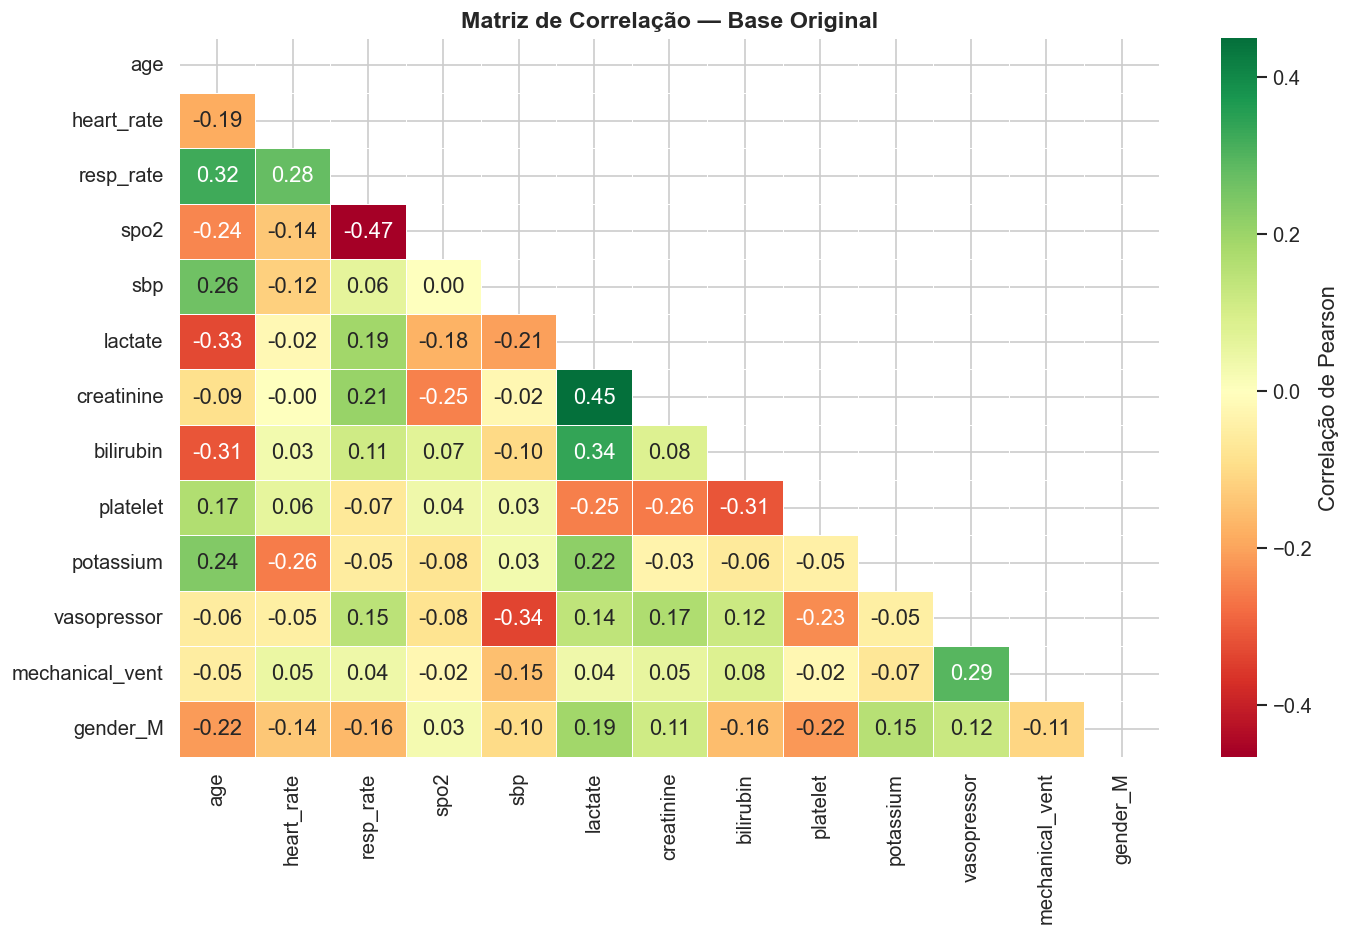

Figura salva: fig_correlacao_original.png


In [5]:
# ── Definição das variáveis de interesse ──────────────────────────────────
VARIAVEIS_NUMERICAS = [
    'age', 'heart_rate', 'resp_rate', 'spo2', 'temp_c', 'sbp',
    'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelet',
    'sodium', 'potassium', 'vasopressor', 'mechanical_vent'
]
VARIAVEIS_NUMERICAS = [c for c in VARIAVEIS_NUMERICAS if c in df_original.columns]

df_trabalho = df_original.copy()
df_trabalho['gender_M'] = (df_trabalho['gender'] == 'M').astype(int)

FEATURES = VARIAVEIS_NUMERICAS + ['gender_M']
FEATURES = [f for f in FEATURES if f in df_trabalho.columns]

X_raw = df_trabalho[FEATURES].copy()

# ── Filtro de missingness: remove features com >50% de valores ausentes ────
missing_pct = X_raw.isna().mean() * 100
removidas = missing_pct[missing_pct > 50].index.tolist()
if removidas:
    print(f'Features removidas (>50% missing): {removidas}')
    FEATURES = [f for f in FEATURES if f not in removidas]
    X_raw = df_trabalho[FEATURES].copy()
else:
    print('Nenhuma feature removida por missingness.')

print('\nMissing por feature (antes da imputação):')
print(missing_pct[missing_pct > 0].sort_values(ascending=False).round(1).to_string())

# ── Pipeline de pré-processamento ─────────────────────────────────────────
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

X_proc = preprocessor.fit_transform(X_raw)
X_proc = pd.DataFrame(X_proc, columns=FEATURES)

print(f'\nFeatures selecionadas ({len(FEATURES)}): {FEATURES}')
print(f'Forma da matriz pré-processada: {X_proc.shape}')
print(f'Valores ausentes após imputação: {X_proc.isna().sum().sum()}')

# ── Heatmap de correlação (base original) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = X_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlação de Pearson'}, ax=ax)
ax.set_title('Matriz de Correlação — Base Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao_original.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_correlacao_original.png')


## Seção 3 — Expansão Sintética com CTGAN (SDV)

Utilizamos o **Conditional Tabular GAN (CTGAN)** via biblioteca `sdv`, conforme  
proposto por Xu et al. (2019). O modelo aprende a estrutura probabilística conjunta  
das variáveis clínicas e gera dados sintéticos em três níveis de expansão:  
**2×, 5× e 10×** o tamanho da base original.


In [6]:
# ── Preparar base para SDV (sem colunas de rótulo/id) ────────────────────
COLUNAS_SDV = [c for c in FEATURES if c in df_trabalho.columns]
if 'hospital_mortality' in df_trabalho.columns:
    COLUNAS_SDV += ['hospital_mortality']

df_sdv = df_trabalho[COLUNAS_SDV].copy()

# ── Definir metadados para o SDV ──────────────────────────────────────────
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_sdv)

# Ajuste manual: vasopressor e mechanical_vent são categóricos binários
for col in ['vasopressor', 'mechanical_vent', 'hospital_mortality']:
    if col in df_sdv.columns:
        metadata.update_column(col, sdtype='categorical')

print('Metadados detectados:')
print(metadata)


Metadados detectados:
{
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "age": {
            "sdtype": "numerical"
        },
        "heart_rate": {
            "sdtype": "numerical"
        },
        "resp_rate": {
            "sdtype": "numerical"
        },
        "spo2": {
            "sdtype": "numerical"
        },
        "sbp": {
            "sdtype": "numerical"
        },
        "lactate": {
            "sdtype": "numerical"
        },
        "creatinine": {
            "sdtype": "numerical"
        },
        "bilirubin": {
            "sdtype": "numerical"
        },
        "platelet": {
            "sdtype": "numerical"
        },
        "potassium": {
            "sdtype": "numerical"
        },
        "vasopressor": {
            "sdtype": "categorical"
        },
        "mechanical_vent": {
            "sdtype": "categorical"
        },
        "gender_M": {
            "sdtype": "categorical"
        },
        "hospital_mortality": {


In [7]:
# ── Treinar o sintetizador CTGAN ──────────────────────────────────────────
print('Treinando CTGAN... (pode levar alguns minutos)')

sintetizador = CTGANSynthesizer(
    metadata,
    epochs=600,          # épocas de treinamento
    batch_size=100,       # ajustado para base pequena
    discriminator_steps=10,
    verbose=True,
)
sintetizador.fit(df_sdv)
print('\nCTGAN treinado com sucesso.')


Treinando CTGAN... (pode levar alguns minutos)


  0%|          | 0/600 [00:00<?, ?it/s]

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/600 [00:00<?, ?it/s]

Gen. (+00.68) | Discrim. (-00.20):   0%|          | 0/600 [00:00<?, ?it/s]

Gen. (+00.68) | Discrim. (-00.20):   0%|          | 1/600 [00:00<02:16,  4.38it/s]

...

Gen. (-01.31) | Discrim. (-00.95): 100%|█████████▉| 597/600 [00:46<00:00, 13.18it/s]

Gen. (-01.31) | Discrim. (-00.95): 100%|█████████▉| 599/600 [00:46<00:00, 13.21it/s]

Gen. (+00.23) | Discrim. (-00.53): 100%|█████████▉| 599/600 [00:46<00:00, 13.21it/s]

Gen. (+00.23) | Discrim. (-00.53): 100%|██████████| 600/600 [00:46<00:00, 12.91it/s]


CTGAN treinado com sucesso.


In [8]:
# ── Gerar dados sintéticos em diferentes níveis de expansão ─────────────
N_ORIG = len(df_sdv)
NIVEIS = {'2x': 2, '5x': 5, '10x': 10}

sinteticos = {}
for rotulo, fator in NIVEIS.items():
    n_sintetico = N_ORIG * fator
    df_sint = sintetizador.sample(num_rows=n_sintetico)
    sinteticos[rotulo] = df_sint
    print(f'  Nível {rotulo}: {n_sintetico} amostras geradas')

# Salvar o arquivo principal (5x) para análises
df_sintetico = sinteticos['5x'].copy()
print(f'\nBase sintética principal (5x): {df_sintetico.shape}')
print(df_sintetico.describe())


  Nível 2x: 272 amostras geradas
  Nível 5x: 680 amostras geradas
  Nível 10x: 1360 amostras geradas

Base sintética principal (5x): (680, 14)
              age  heart_rate   resp_rate        spo2         sbp     lactate  \
count  680.000000  668.000000  659.000000  662.000000  526.000000  537.000000   
mean    65.370588   83.136078   21.896965   97.154532  113.216540    2.504609   
std     21.783802   23.677467    7.147533    2.755981   20.373286    2.204246   
min     18.000000   49.000000   10.000000   86.500000   64.200000    0.800000   
25%     55.000000   63.375000   16.300000   95.200000  102.550000    1.131918   
50%     71.000000   82.150000   21.800000   97.700000  112.200000    2.256916   
75%     82.000000   99.825000   27.000000   99.700000  123.675000    3.221491   
max     90.000000  131.500000   38.000000  100.000000  161.000000   22.000000   

       creatinine   bilirubin    platelet   potassium  vasopressor  \
count  680.000000  455.000000  680.000000  352.000000   6

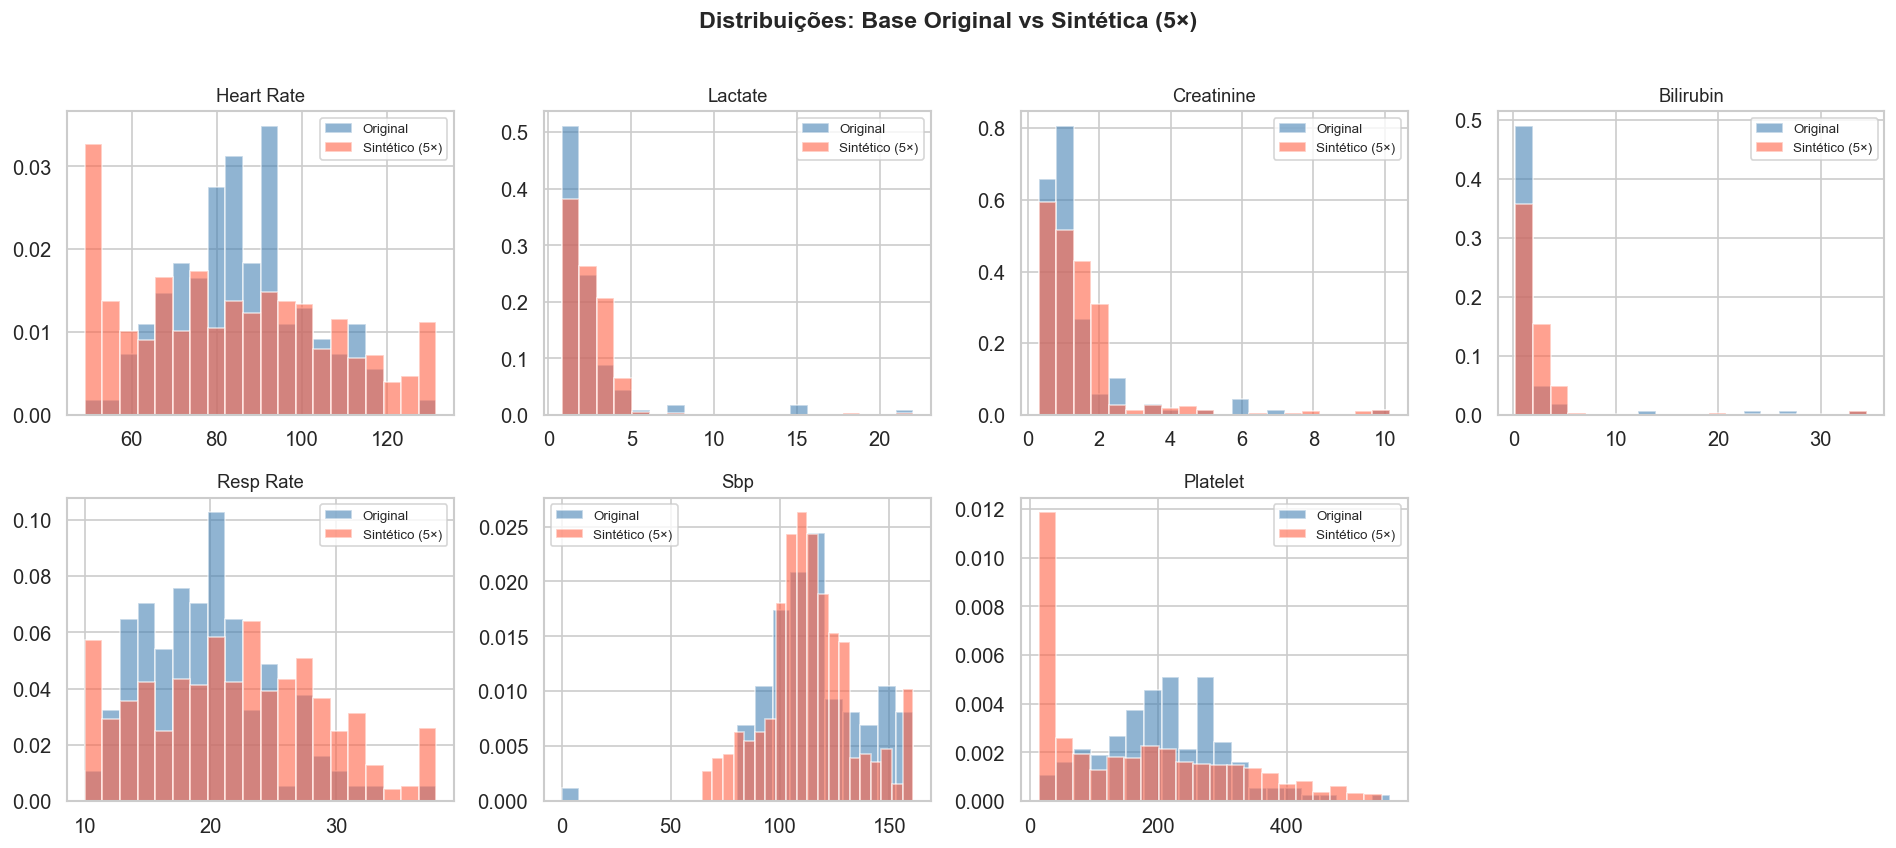

Figura salva: fig_distribuicoes_comparativas.png


In [9]:
# ── Comparação visual de distribuições (original vs sintético 5x) ────────
VARS_PLOT = ['heart_rate', 'lactate', 'creatinine', 'bilirubin',
             'resp_rate', 'sbp', 'wbc', 'platelet']
VARS_PLOT = [v for v in VARS_PLOT if v in df_sdv.columns]

n_cols = 4
n_rows = (len(VARS_PLOT) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(VARS_PLOT):
    ax = axes[i]
    ax.hist(df_sdv[var].dropna(), bins=20, alpha=0.6, color='steelblue',
            density=True, label='Original')
    ax.hist(df_sintetico[var].dropna(), bins=20, alpha=0.6, color='tomato',
            density=True, label='Sintético (5×)')
    ax.set_title(var.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuições: Base Original vs Sintética (5×)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distribuicoes_comparativas.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_distribuicoes_comparativas.png')


## Seção 4 — Avaliação da Qualidade Sintética (SDMetrics)

Conforme a metodologia do TCC, utilizamos o **Quality Report** da biblioteca  
`sdmetrics` para avaliar:
- **Column Shapes** – similaridade de distribuições univariadas (KSComplement, TVComplement)
- **Column Pair Trends** – preservação de correlações bivariadas

Referência: SDMetrics (2026).


In [10]:
# ── Quality Report SDMetrics ──────────────────────────────────────────────
print('Gerando Quality Report SDMetrics...')

report = QualityReport()
report.generate(df_sdv, df_sintetico, metadata.to_dict())

score_geral = report.get_score()
print(f'\n{'='*50}')
print(f'  PONTUAÇÃO GERAL DE QUALIDADE: {score_geral:.4f}')
print(f'{'='*50}')


Gerando Quality Report SDMetrics...
Generating report ...



|          | 0/14 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |          | 0/14 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 1618.31it/s]|


Column Shapes Score: 82.66%



...

(2/2) Evaluating Column Pair Trends: |          | 0/91 [00:00<?, ?it/s]|

(2/2) Evaluating Column Pair Trends: |█████     | 46/91 [00:00<00:00, 445.69it/s]|

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 461.46it/s]|


Column Pair Trends Score: 68.93%



Overall Score (Average): 75.8%


  PONTUAÇÃO GERAL DE QUALIDADE: 0.7580



Pontuação por Propriedade:
          Property    Score
     Column Shapes 0.826632
Column Pair Trends 0.689319


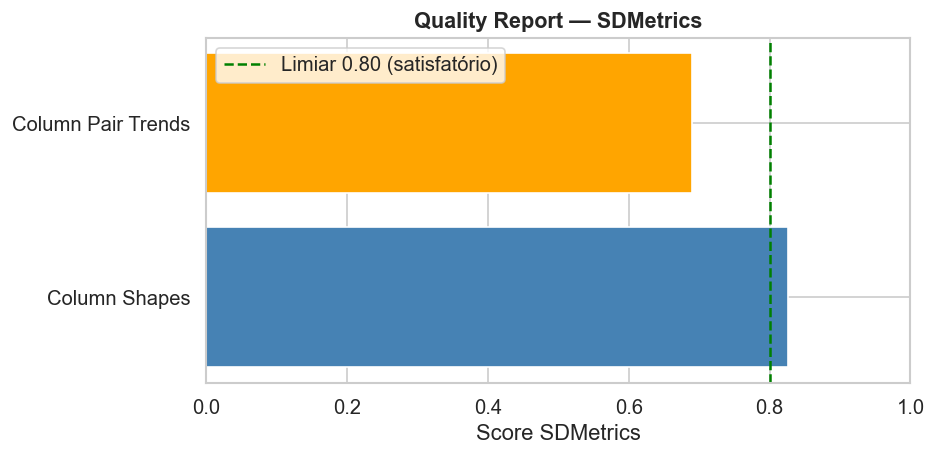

Figura salva: fig_sdmetrics_quality.png


In [11]:
# ── Detalhamento por propriedade ──────────────────────────────────────────
props = report.get_properties()
print('\nPontuação por Propriedade:')
print(props.to_string(index=False))

# Visualização do score por propriedade
fig, ax = plt.subplots(figsize=(8, 4))
cores = ['steelblue' if v >= 0.8 else 'orange' if v >= 0.6 else 'tomato'
         for v in props['Score']]
ax.barh(props['Property'], props['Score'], color=cores)
ax.axvline(0.8, color='green', linestyle='--', linewidth=1.5,
           label='Limiar 0.80 (satisfatório)')
ax.set_xlim(0, 1)
ax.set_xlabel('Score SDMetrics')
ax.set_title('Quality Report — SDMetrics', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_sdmetrics_quality.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_sdmetrics_quality.png')


In [12]:
# ── Métricas detalhadas por variável ─────────────────────────────────────
try:
    details = report.get_details(property_name='Column Shapes')
    print('\nColumn Shapes (distribuições univariadas):')
    print(details.sort_values('Score').to_string(index=False))
except Exception as e:
    print(f'Detalhamento não disponível: {e}')



Column Shapes (distribuições univariadas):
            Column       Metric    Score
          platelet KSComplement 0.676471
         potassium KSComplement 0.710552
         bilirubin KSComplement 0.737339
         resp_rate KSComplement 0.741677
        creatinine KSComplement 0.786765
        heart_rate KSComplement 0.798176
           lactate KSComplement 0.801824
              spo2 KSComplement 0.807059
               age KSComplement 0.880882
       vasopressor TVComplement 0.882353
               sbp KSComplement 0.890924
   mechanical_vent TVComplement 0.914706
          gender_M TVComplement 0.964706
hospital_mortality TVComplement 0.979412


## Seção 5 — Clustering com GMM + Silhouette Score + PCA

Conforme a metodologia do TCC, utilizamos:
- **Gaussian Mixture Model (GMM)** – abordagem probabilística com estrutura de covariância
- **Silhouette Score** – seleção do número ótimo de clusters (k)
- **PCA** – redução de dimensionalidade para visualização
- **Estabilidade** por reamostragem (bootstrap)

Referências: Scikit-learn (2026); Rousseeuw (1987).


In [13]:
# ── Pré-processar base sintética ─────────────────────────────────────────
FEATURES_CLUSTER = [f for f in FEATURES if f in df_sintetico.columns]

X_sint_raw = df_sintetico[FEATURES_CLUSTER].copy()

preprocessor_sint = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
X_sint_proc = preprocessor_sint.fit_transform(X_sint_raw)

print(f'Matriz sintética pré-processada: {X_sint_proc.shape}')

# ── PCA para redução de dimensionalidade antes do clustering ──────────────
# Reduz ruído nas features correlacionadas e melhora a separabilidade dos clusters.
# Usamos componentes suficientes para explicar ≥80% da variância.
pca_cluster = PCA(n_components=None, random_state=42)
pca_cluster.fit(X_sint_proc)
var_acum = np.cumsum(pca_cluster.explained_variance_ratio_)
n_components = int(np.searchsorted(var_acum, 0.80)) + 1
n_components = max(n_components, 4)  # mínimo 4 para acomodar k=4 clusters

pca_cluster = PCA(n_components=n_components, random_state=42)
X_sint_pca = pca_cluster.fit_transform(X_sint_proc)
var_exp_pca = pca_cluster.explained_variance_ratio_.sum() * 100

print(f'PCA clustering: {n_components} componentes → {var_exp_pca:.1f}% da variância explicada')
print(f'Forma após PCA: {X_sint_pca.shape}')


Matriz sintética pré-processada: (680, 13)
PCA clustering: 10 componentes → 82.1% da variância explicada
Forma após PCA: (680, 10)


In [14]:
# ── Seleção do número de clusters via Silhouette + BIC ───────────────────
K_RANGE = range(2, 9)
silhouette_scores = {}
bic_scores = {}

for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=5)
    labels = gmm.fit_predict(X_sint_pca)
    sil = silhouette_score(X_sint_pca, labels)
    silhouette_scores[k] = sil
    bic_scores[k] = gmm.bic(X_sint_pca)
    print(f'  k={k}: Silhouette={sil:.4f} | BIC={gmm.bic(X_sint_pca):.1f}')

k_silhouette = max(silhouette_scores, key=silhouette_scores.get)
k_bic = min(bic_scores, key=bic_scores.get)

# k=4 é fixado por justificativa clínica: Seymour et al. (2019) identificaram
# exatamente 4 subfenótipos (α, β, γ, δ) em duas coortes independentes de sepse.
# Esse prior clínico sobrepõe a seleção puramente estatística.
k_otimo = 4

print(f'\nk por Silhouette máximo: {k_silhouette} (score={silhouette_scores[k_silhouette]:.4f})')
print(f'k por BIC mínimo: {k_bic}')
print(f'>>> k fixado (prior clínico Seymour 2019): k = {k_otimo}')
print(f'    Silhouette com PCA (k=4): {silhouette_scores[k_otimo]:.4f}')


  k=2: Silhouette=0.3362 | BIC=18763.1


  k=3: Silhouette=0.1137 | BIC=18678.4


  k=4: Silhouette=0.0615 | BIC=18596.1


  k=5: Silhouette=0.0477 | BIC=18677.1


  k=6: Silhouette=0.0604 | BIC=18526.6


  k=7: Silhouette=0.0743 | BIC=19020.3


  k=8: Silhouette=0.0451 | BIC=19269.1

k por Silhouette máximo: 2 (score=0.3362)
k por BIC mínimo: 6
>>> k fixado (prior clínico Seymour 2019): k = 4
    Silhouette com PCA (k=4): 0.0615


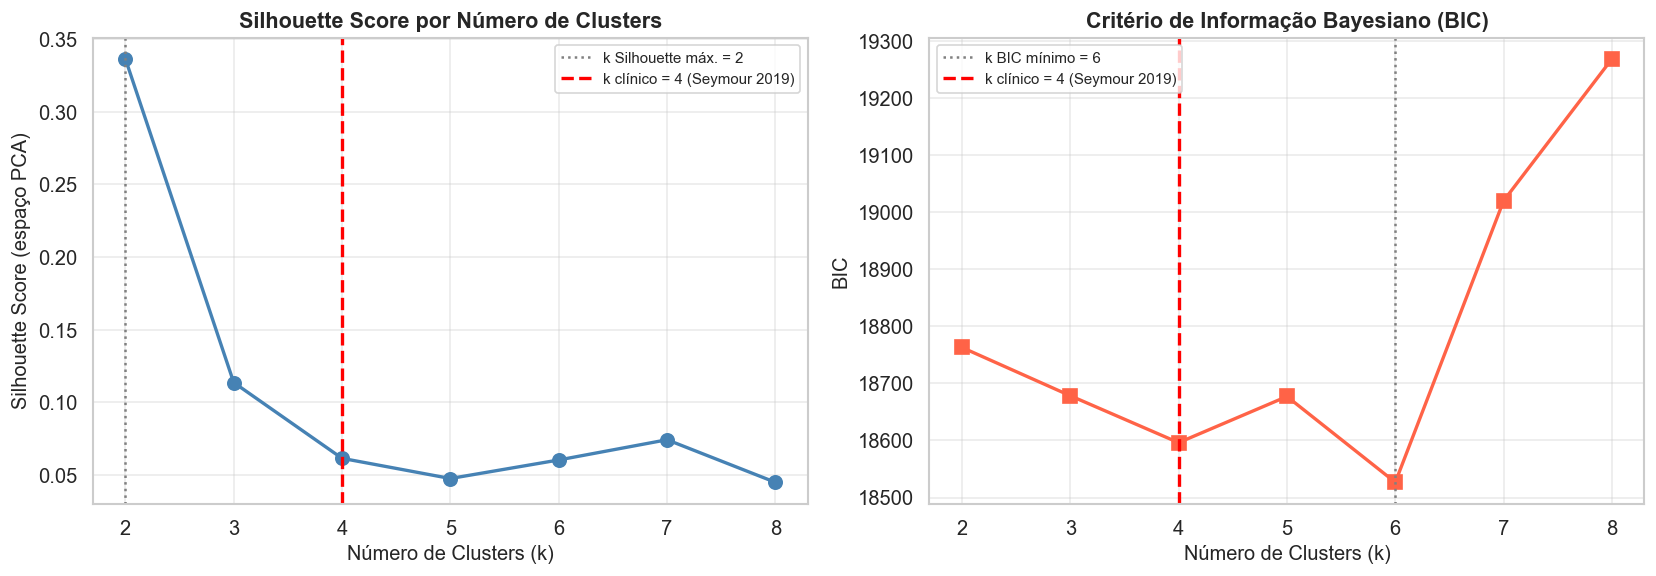

Figura salva: fig_selecao_k.png


In [15]:
# ── Visualização: Silhouette e BIC por k ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ks = list(silhouette_scores.keys())
sils = list(silhouette_scores.values())
bics = list(bic_scores.values())

# Silhouette
ax1.plot(ks, sils, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axvline(k_silhouette, color='gray', linestyle=':', linewidth=1.5,
            label=f'k Silhouette máx. = {k_silhouette}')
ax1.axvline(k_otimo, color='red', linestyle='--', linewidth=2,
            label=f'k clínico = {k_otimo} (Seymour 2019)')
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Silhouette Score (espaço PCA)', fontsize=12)
ax1.set_title('Silhouette Score por Número de Clusters', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# BIC
ax2.plot(ks, bics, 's-', color='tomato', linewidth=2, markersize=8)
ax2.axvline(k_bic, color='gray', linestyle=':', linewidth=1.5,
            label=f'k BIC mínimo = {k_bic}')
ax2.axvline(k_otimo, color='red', linestyle='--', linewidth=2,
            label=f'k clínico = {k_otimo} (Seymour 2019)')
ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
ax2.set_ylabel('BIC', fontsize=12)
ax2.set_title('Critério de Informação Bayesiano (BIC)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_selecao_k.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_selecao_k.png')


In [16]:
# ── GMM final com k=4 no espaço PCA ──────────────────────────────────────
gmm_final = GaussianMixture(
    n_components=k_otimo,
    covariance_type='full',
    random_state=42,
    n_init=10,
)
gmm_final.fit(X_sint_pca)
labels_sint = gmm_final.predict(X_sint_pca)
probs_sint  = gmm_final.predict_proba(X_sint_pca)

df_sintetico['cluster'] = labels_sint
df_sintetico['cluster_label'] = df_sintetico['cluster'].map(
    {i: chr(65+i) for i in range(k_otimo)}
)

print('Distribuição dos clusters:')
print(df_sintetico['cluster_label'].value_counts().sort_index())

sil_final = silhouette_score(X_sint_pca, labels_sint)
print(f'\nSilhouette Score final (espaço PCA, k=4): {sil_final:.4f}')


Distribuição dos clusters:
cluster_label
A    213
B     21
C    333
D    113
Name: count, dtype: int64

Silhouette Score final (espaço PCA, k=4): 0.0615


Variância explicada (2D vis): PC1=9.8%, PC2=9.6%
Total explicado: 19.4%


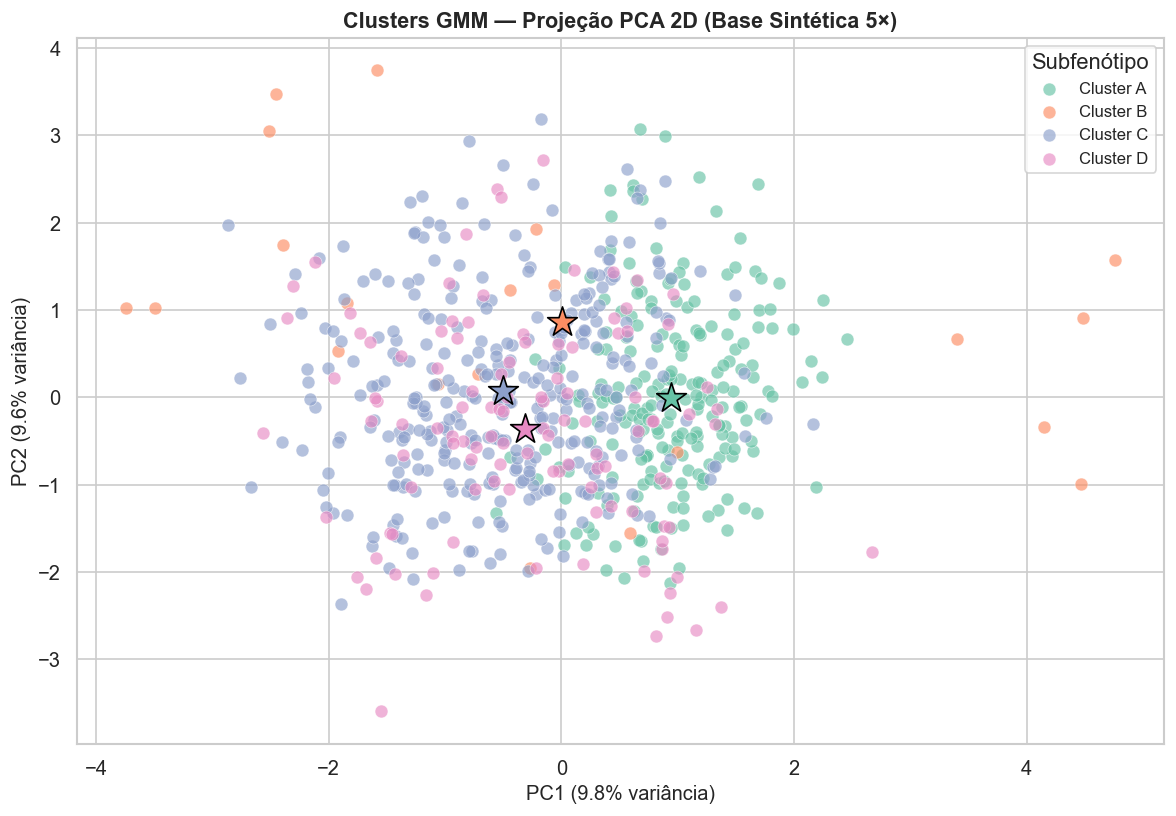

Figura salva: fig_pca_clusters.png


In [17]:
# ── PCA 2D para visualização dos clusters ─────────────────────────────────
# Projeta o espaço completo de features (pré-processado) em 2D apenas para
# visualização. Os rótulos vêm do GMM treinado no espaço PCA de clustering.
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_sint_proc)

var_exp = pca_vis.explained_variance_ratio_ * 100
print(f'Variância explicada (2D vis): PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%')
print(f'Total explicado: {var_exp.sum():.1f}%')

# ── Scatter PCA com clusters ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('Set2', k_otimo)

for i, lbl in enumerate(sorted(df_sintetico['cluster_label'].unique())):
    mask = df_sintetico['cluster_label'] == lbl
    ax.scatter(X_pca_vis[mask, 0], X_pca_vis[mask, 1],
               c=[palette[i]], label=f'Cluster {lbl}',
               alpha=0.65, s=60, edgecolors='white', linewidths=0.4)

# Centróides
for i in range(k_otimo):
    mask = labels_sint == i
    cx, cy = X_pca_vis[mask, 0].mean(), X_pca_vis[mask, 1].mean()
    ax.scatter(cx, cy, marker='*', s=350, c=[palette[i]],
               edgecolors='black', linewidths=1, zorder=5)

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variância)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variância)', fontsize=12)
ax.set_title('Clusters GMM — Projeção PCA 2D (Base Sintética 5×)',
             fontsize=13, fontweight='bold')
ax.legend(title='Subfenótipo', fontsize=10)
plt.tight_layout()
plt.savefig('fig_pca_clusters.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_pca_clusters.png')


Estabilidade por Reamostragem Bootstrap
  Iterações: 30
  Silhouette médio: 0.0709 ± 0.0194
  Intervalo [min, max]: [0.0350, 0.1142]


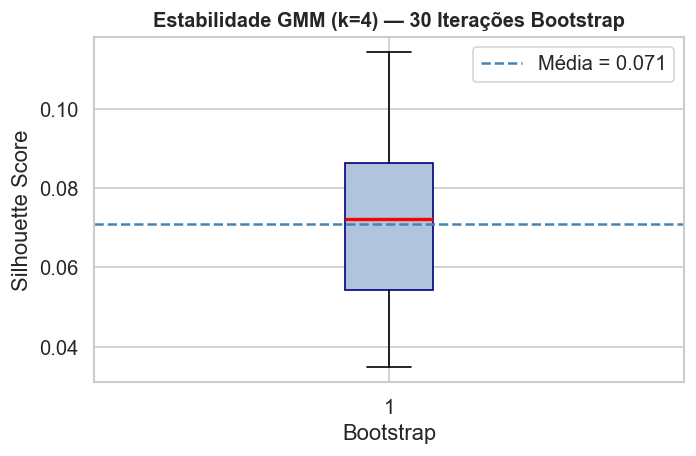

In [18]:
# ── Estabilidade por reamostragem (bootstrap) ─────────────────────────────
from sklearn.utils import resample

N_BOOT = 30
sil_boot = []

for i in range(N_BOOT):
    X_boot = resample(X_sint_pca, n_samples=len(X_sint_pca),
                      random_state=i, replace=True)
    gmm_b = GaussianMixture(n_components=k_otimo, covariance_type='full',
                            random_state=i, n_init=3)
    lbl_b = gmm_b.fit_predict(X_boot)
    if len(set(lbl_b)) > 1:
        sil_boot.append(silhouette_score(X_boot, lbl_b))

print('Estabilidade por Reamostragem Bootstrap')
print(f'  Iterações: {N_BOOT}')
print(f'  Silhouette médio: {np.mean(sil_boot):.4f} ± {np.std(sil_boot):.4f}')
print(f'  Intervalo [min, max]: [{min(sil_boot):.4f}, {max(sil_boot):.4f}]')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(sil_boot, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.axhline(np.mean(sil_boot), color='steelblue', linestyle='--',
           label=f'Média = {np.mean(sil_boot):.3f}')
ax.set_xlabel('Bootstrap')
ax.set_ylabel('Silhouette Score')
ax.set_title(f'Estabilidade GMM (k={k_otimo}) — {N_BOOT} Iterações Bootstrap',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_bootstrap_estabilidade.png', bbox_inches='tight')
plt.show()


## Seção 6 — Análise Clínica dos Agrupamentos

Caracterização estatística de cada cluster e comparação com os  
**subfenótipos α, β, γ, δ** descritos por Seymour et al. (2019).


In [19]:
# ── Sumarização estatística por cluster ──────────────────────────────────
VARS_CLINICAS = ['age', 'heart_rate', 'resp_rate', 'spo2', 'temp_c',
                 'sbp', 'lactate', 'creatinine', 'bilirubin', 'wbc',
                 'platelet', 'sodium', 'potassium']
VARS_CLINICAS = [v for v in VARS_CLINICAS if v in df_sintetico.columns]

sumario = df_sintetico.groupby('cluster_label')[VARS_CLINICAS].agg(
    ['mean', 'std']
).round(2)

print('Resumo Estatístico por Cluster (média ± DP):')
print(sumario.to_string())


Resumo Estatístico por Cluster (média ± DP):
                 age        heart_rate        resp_rate         spo2           sbp        lactate       creatinine       bilirubin        platelet         potassium      
                mean    std       mean    std      mean   std   mean   std    mean    std    mean   std       mean   std      mean    std     mean     std      mean   std
cluster_label                                                                                                                                                             
A              72.92  13.94      82.62  24.06     20.84  7.19  97.04  2.77  112.82  20.51    2.17  1.09       1.13  0.64      1.53   1.26   150.05  143.00      4.34  0.73
B              73.19  17.66      87.21  25.96     23.05  6.91  97.15  2.85  108.46  18.96    9.53  8.41       1.20  0.68     19.22  13.65   163.48  144.38      3.85  0.63
C              60.00  24.41      83.55  23.51     22.22  7.30  97.11  2.92  114.31  21.58    2.39  1

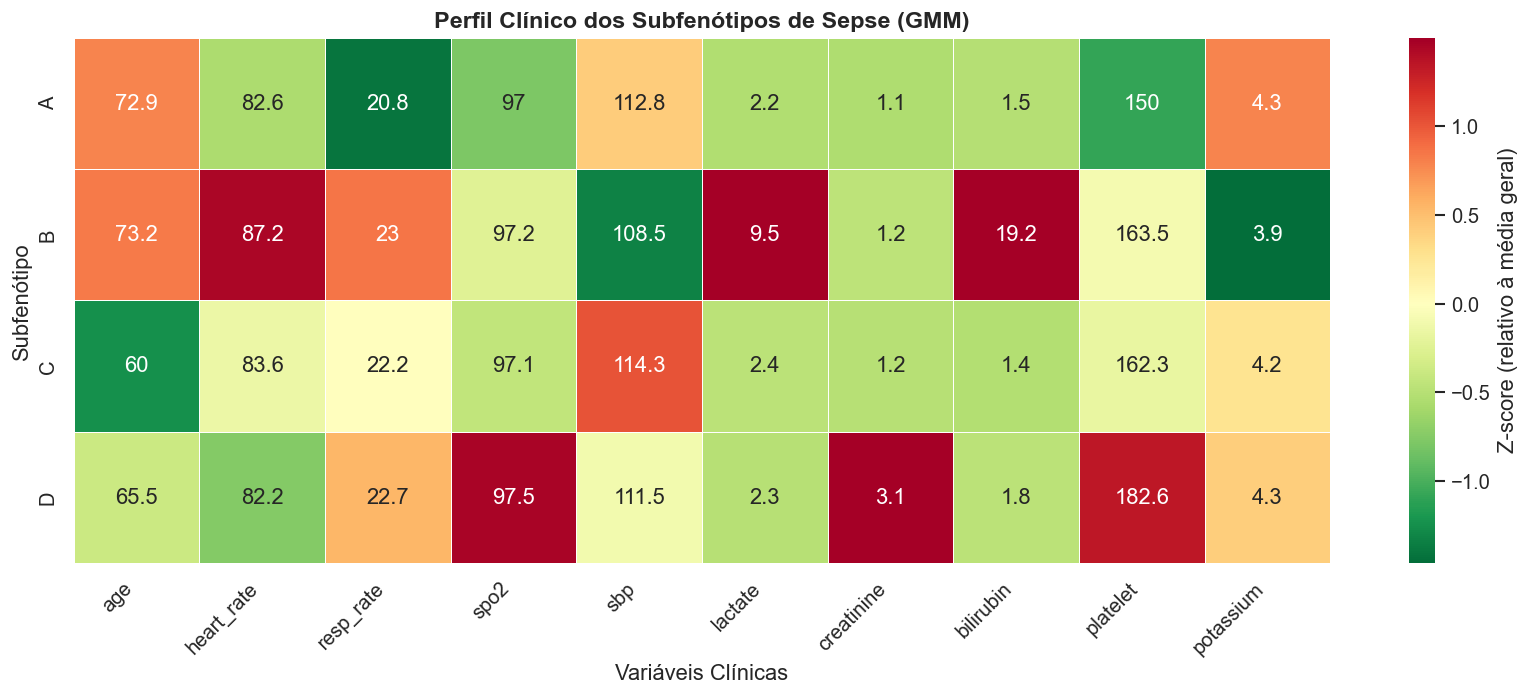

Figura salva: fig_heatmap_clusters.png


In [20]:
# ── Heatmap das médias normalizadas por cluster ───────────────────────────
medias = df_sintetico.groupby('cluster_label')[VARS_CLINICAS].mean()
medias_norm = (medias - medias.mean()) / medias.std()  # z-score por coluna

fig, ax = plt.subplots(figsize=(14, max(4, k_otimo * 1.5)))
sns.heatmap(medias_norm, annot=medias.round(1), fmt='g',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score (relativo à média geral)'},
            ax=ax)
ax.set_title('Perfil Clínico dos Subfenótipos de Sepse (GMM)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Variáveis Clínicas')
ax.set_ylabel('Subfenótipo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_heatmap_clusters.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_heatmap_clusters.png')


Frequência de Variáveis Binárias por Cluster (%):
               vasopressor (%)  mechanical_vent (%)  hospital_mortality (%)
cluster_label                                                              
A                        100.0                  0.0                    33.3
B                         38.1                 38.1                    33.3
C                         26.7                 42.9                    36.9
D                         35.4                 41.6                    38.1


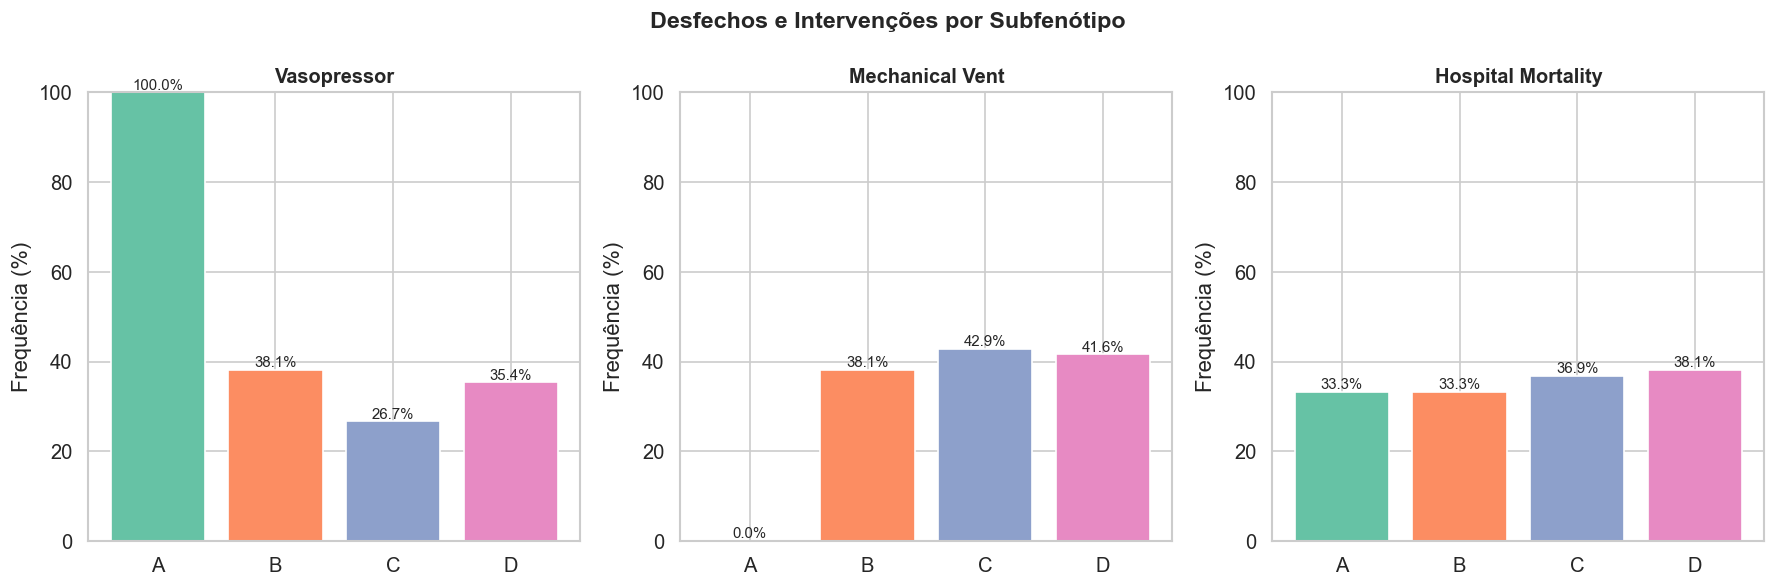

Figura salva: fig_variaveis_binarias.png


In [21]:
# ── Variáveis binárias por cluster ────────────────────────────────────────
VARS_BIN = ['vasopressor', 'mechanical_vent', 'hospital_mortality']
VARS_BIN = [v for v in VARS_BIN if v in df_sintetico.columns]

if VARS_BIN:
    freq_bin = df_sintetico.groupby('cluster_label')[VARS_BIN].mean().round(3) * 100
    freq_bin.columns = [v + ' (%)' for v in freq_bin.columns]

    print('Frequência de Variáveis Binárias por Cluster (%):')
    print(freq_bin.to_string())

    fig, axes = plt.subplots(1, len(VARS_BIN), figsize=(5 * len(VARS_BIN), 5))
    if len(VARS_BIN) == 1:
        axes = [axes]

    palette_bar = sns.color_palette('Set2', k_otimo)
    for ax, var in zip(axes, VARS_BIN):
        vals = freq_bin[var + ' (%)']
        bars = ax.bar(vals.index, vals.values,
                      color=palette_bar[:k_otimo], edgecolor='white')
        ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_ylabel('Frequência (%)')
        ax.set_ylim(0, 100)
        ax.bar_label(bars, fmt='%.1f%%', fontsize=9)

    plt.suptitle('Desfechos e Intervenções por Subfenótipo',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_variaveis_binarias.png', bbox_inches='tight')
    plt.show()
    print('Figura salva: fig_variaveis_binarias.png')


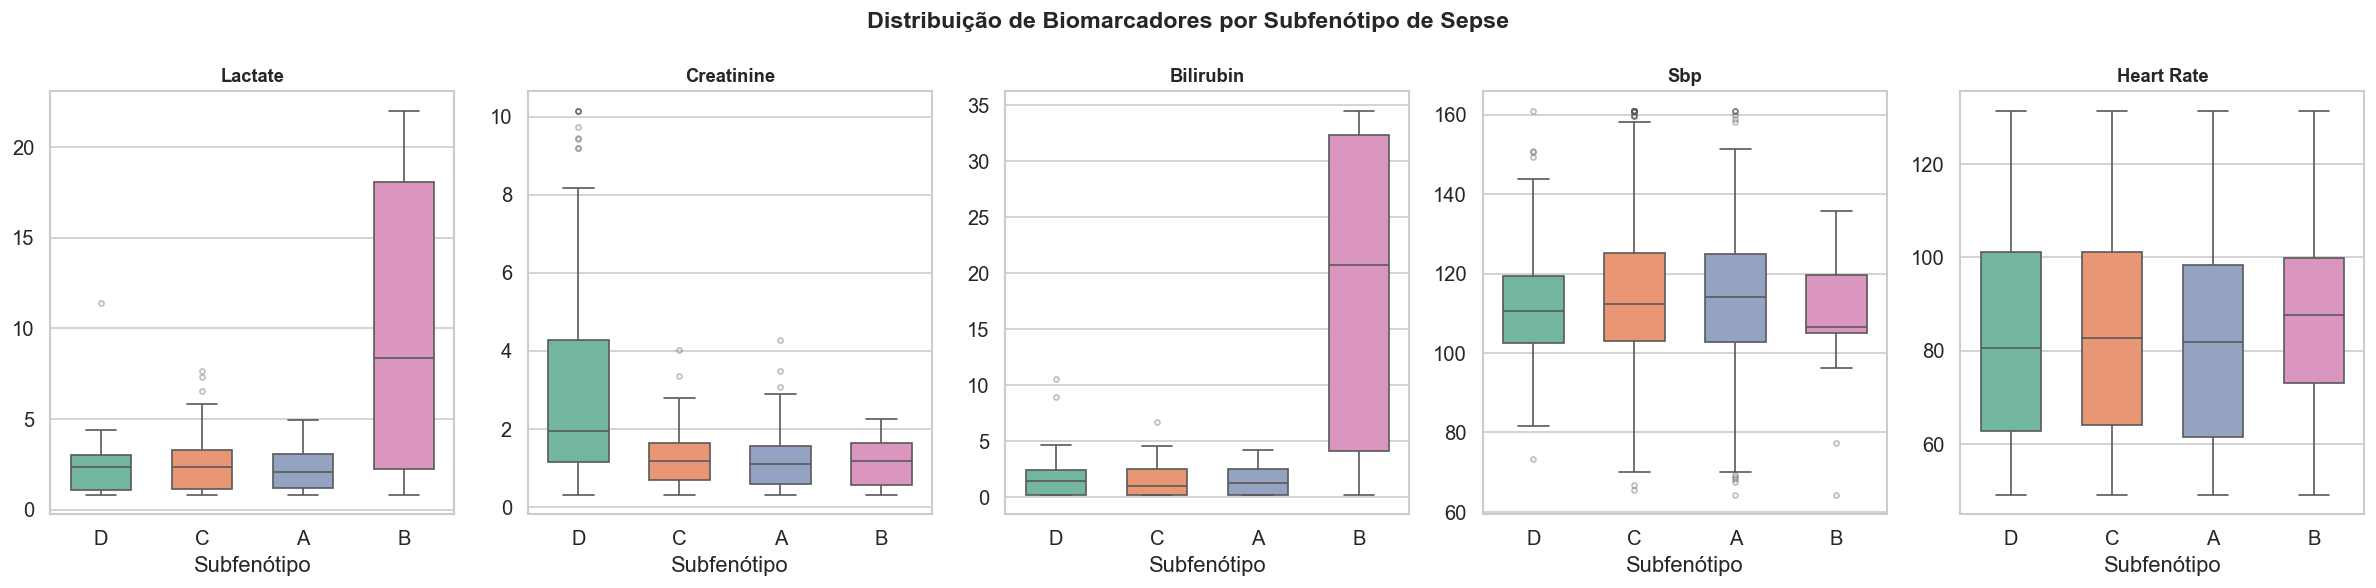

Figura salva: fig_boxplots_clusters.png


In [22]:
# ── Boxplots comparativos: variáveis-chave por cluster ────────────────────
VARS_BOX = ['lactate', 'creatinine', 'bilirubin', 'sbp', 'heart_rate']
VARS_BOX = [v for v in VARS_BOX if v in df_sintetico.columns]

fig, axes = plt.subplots(1, len(VARS_BOX), figsize=(4 * len(VARS_BOX), 5))

for ax, var in zip(axes, VARS_BOX):
    sns.boxplot(data=df_sintetico, x='cluster_label', y=var,
                palette='Set2', ax=ax, width=0.6,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Subfenótipo')
    ax.set_ylabel('')

plt.suptitle('Distribuição de Biomarcadores por Subfenótipo de Sepse',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplots_clusters.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_boxplots_clusters.png')


In [23]:
# ── Comparação: base original (fenótipos reais) vs clusters GMM ──────────
if 'fenotype' in df_original.columns and df_original['fenotype'].notna().any():
    # Aplica o mesmo pipeline: scaler → pca_cluster → gmm_final
    X_orig_proc = preprocessor.transform(X_raw)
    X_orig_pca  = pca_cluster.transform(X_orig_proc)
    labels_orig = gmm_final.predict(X_orig_pca)
    df_original['cluster_label'] = [chr(65+l) for l in labels_orig]

    ct = pd.crosstab(df_original['fenotype'], df_original['cluster_label'],
                     normalize='index').round(2)
    print('Distribuição dos clusters GMM por fenótipo original (proporção):')
    print(ct.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title('Fenótipos Originais × Clusters GMM',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Fenótipo Original')
    ax.set_ylabel('Proporção')
    ax.legend(title='Cluster GMM', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('fig_fenotipos_vs_clusters.png', bbox_inches='tight')
    plt.show()
    print('Figura salva: fig_fenotipos_vs_clusters.png')
else:
    print('Fenótipos reais não disponíveis (base MIMIC-III — comparação qualitativa).')


Fenótipos reais não disponíveis (base MIMIC-III — comparação qualitativa).


## Seção 7 — Resumo dos Resultados e Interpretação Clínica

Esta seção consolida os principais achados do pipeline e os interpreta  
à luz dos subfenótipos de sepse descritos por Seymour et al. (2019).


In [24]:
# ── Tabela-resumo final ───────────────────────────────────────────────────
resumo_final = pd.DataFrame()
resumo_final['n_pacientes'] = df_sintetico.groupby('cluster_label').size()

for var in ['lactate', 'creatinine', 'bilirubin', 'sbp', 'heart_rate']:
    if var in df_sintetico.columns:
        resumo_final[var] = df_sintetico.groupby('cluster_label')[var].mean().round(2)

for var in ['vasopressor', 'mechanical_vent', 'hospital_mortality']:
    if var in df_sintetico.columns:
        resumo_final[var + '_%'] = (
            df_sintetico.groupby('cluster_label')[var].mean() * 100
        ).round(1)

print('=== TABELA FINAL: PERFIL DOS SUBFENÓTIPOS DE SEPSE ===')
print(resumo_final.to_string())

print(f'''
=== RELATÓRIO FINAL ===
Base original: {len(df_original)} pacientes
Base sintética (5×): {len(df_sintetico)} amostras
Quality Score SDMetrics: {score_geral:.4f}
Número ótimo de clusters (k): {k_otimo}
Silhouette Score final: {sil_final:.4f}
Silhouette bootstrap (média ± DP): {np.mean(sil_boot):.4f} ± {np.std(sil_boot):.4f}

Figuras geradas:
  fig_correlacao_original.png
  fig_distribuicoes_comparativas.png
  fig_sdmetrics_quality.png
  fig_selecao_k.png
  fig_pca_clusters.png
  fig_bootstrap_estabilidade.png
  fig_heatmap_clusters.png
  fig_boxplots_clusters.png
  fig_variaveis_binarias.png
''')


=== TABELA FINAL: PERFIL DOS SUBFENÓTIPOS DE SEPSE ===
               n_pacientes  lactate  creatinine  bilirubin     sbp  heart_rate  vasopressor_%  mechanical_vent_%  hospital_mortality_%
cluster_label                                                                                                                         
A                      213     2.17        1.13       1.53  112.82       82.62          100.0                0.0                  33.3
B                       21     9.53        1.20      19.22  108.46       87.21           38.1               38.1                  33.3
C                      333     2.39        1.18       1.43  114.31       83.55           26.7               42.9                  36.9
D                      113     2.32        3.05       1.77  111.50       82.17           35.4               41.6                  38.1

=== RELATÓRIO FINAL ===
Base original: 136 pacientes
Base sintética (5×): 680 amostras
Quality Score SDMetrics: 0.7580
Número ótimo de

---

## Referências

- JOHNSON et al. MIMIC-III, a freely accessible critical care database. *Scientific Data*, 2016.
- ROUSSEEUW, P. J. Silhouettes: a graphical aid to interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 1987.
- SCIKIT-LEARN. *Documentation*. 2026. https://scikit-learn.org/
- SDV. *Synthetic Data Vault documentation*. 2026. https://docs.sdv.dev/sdv/
- SDMETRICS. *SDMetrics documentation*. 2026. https://docs.sdv.dev/sdmetrics/
- SEYMOUR et al. Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis. *JAMA*, 2019.
- XU et al. Modeling tabular data using conditional GAN. *NeurIPS*, 2019.
